![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Proyecto1: Construcción e implementación de modelos Random Forest y XGBoost

Este notebook comprende la calibración y entrenamiento de los modelos de predicción de popularidad de canciones y es parte del proyecto 1 del curso de Machine Learning y Procesamiento de Lenguaje Natural de la Maestría en Inteligencia Analítica de Datos (MIAD)

**Para la competencia de deberá utilizar los datos de test:** 

dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/dataTest_Spotify.csv', index_col=0)

**Para calibrar y entrenar los modelos los sets de train y test de cada modelo se encuentran en la carpeta "datos":**

Para random forest se excluyeron las variables categóricas 'artists', 'album_name','track_name','track_genre' y se codificó la variable explicit: 

X_train_rf.csv
X_test_rf.csv
y_train_rf.csv
y_test_rf.csv

Para XGBoost se utilizan todas las variables sin codificar ni escalar:

X_train_xgboost.csv
X_test_xgboost.csv
y_train_xgboost.csv
y_test_xgboost.csv 


## Random Forest 

In [ ]:
import warnings
#warnings.filterwarnings('ignore')

In [ ]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np

In [ ]:


# Lectura de los datos para calibración y entrenamiento de random forest 
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

X_train_rf = pd.read_csv("datos/X_train_rf.csv")
X_test_rf = pd.read_csv("datos/X_test_rf.csv")
y_train_rf = pd.read_csv("datos/y_train_rf.csv").squeeze()
y_test_rf = pd.read_csv("datos/y_test_rf.csv").squeeze()

In [ ]:
# Celda 4
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Definición de modelo Random Forest para un problema de regresión
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train_rf, y_train_rf)


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import median_absolute_error


# Prediccion Y Evaluación del Modelo
y_pred = model_rf.predict(X_test_rf)
rmse =np.sqrt(mean_squared_error(y_test_rf, y_pred))
mae = median_absolute_error(y_test_rf, y_pred)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(y_test_rf, y_pred, alpha=0.7)
plt.xlabel('Valores Reales')
plt.ylabel('Valores de predicción')
plt.title('Comparativo de los Valores Reales vs Valores de predicción')
plt.plot([min(y_test_rf), max(y_test_rf)], [min(y_test_rf), max(y_test_rf)], color='red')
plt.grid(True)
plt.show()

In [ ]:
# Visualización básica de la importancia de características
plt.figure(figsize=(8, 5))
plt.barh(X_train_rf.columns, model_rf.feature_importances_)
plt.xlabel('Peso por característica en la predicción')
plt.title('Peso por característica en la predicción - Modelo Random Forest')
plt.tight_layout()
plt.show()


## **<span style="color:red">Hasta aca hice cambios en Random FOREST</span>**


### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Random Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

**Antes de hacer la calibración de los parametros se hará una validación cruzada sobre X_train con el modelo sin calibrar para poder hacer una comparación antes y despues de la calibración**. 

##### Validación Cruzada Modelo Sin Calibración de Parámetros. 



In [ ]:
rmse_scores = pd.Series(-cross_val_score(model_rf, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error'))
print(pd.Series(rmse_scores).describe())

In [ ]:
#MAE
mae_scores = -cross_val_score(model_rf, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
print(pd.Series(mae_scores).describe())

Las métricas obtenidas de la validación cruzada con el scoring fijado en el valor negativo del RMSE nos indican que el modelo es relativamente estable,  con una desviación estandar del error 60.71 pequeña comparada con el promedio obtenido: **1737.51** Por su parte las métricas obtenidas con el socring fiajdo en el valor negativo del MAE tambiên son aun más estables con un promedio de **1298.86** y una desviación estandar de 37.67

No se ahondará en el análisis de estas métricas dado que solo utilizaremos el promedio del **RMSE = 1737.51** y del **MAE = 1298.86** como referencia para comparar los resultados obtenidos con la calibración en los siguientes pasos.

##### Calibración max_depth

**max_depth** es la profundidad que se debe considerar en cada árbol.

In [ ]:
# Creación de lista de valores para iterar sobre diferentes valores de max_depth
depth_range = range(5, 20,5)

# Definición de lista para almacenar la exactitud (rmse) promedio para cada valor de max_depth
rmse_max_depth_scores = []

# Uso de un 5-fold cross-validation para cada valor de max_depth
for depth in depth_range:
    Rgr = RandomForestRegressor(max_depth=depth, random_state=1, n_jobs=-1)
    rmse_max_depth_scores.append(-(cross_val_score(Rgr, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()))

In [ ]:
# Mejor RMSE
best_index = np.argmin(rmse_max_depth_scores)
best_max_depth = depth_range[best_index]
best_rmse = rmse_max_depth_scores[best_index]

print(f"Mejor parámetro max_depth: {best_max_depth}")
print(f"Mejor RMSE: {best_rmse:.4f}")

In [ ]:
# Gráfica del desempeño del modelo vs la cantidad de max_features
plt.figure(figsize=(4, 4))
plt.plot(depth_range, rmse_max_depth_scores)
plt.xlabel('max_depth')
plt.ylabel('neg_mean_squared_error')
plt.show()

##### Calibración max_features

**max_features** es el número de variables que se deben considerar en cada árbol.

In [ ]:
# Creación de lista de valores para iterar sobre diferentes valores de max_features
feature_range = range(1, X_train.shape[1] + 1)

# Definición de lista para almacenar la exactitud (mse) promedio para cada valor de max_features
rmse_max_features_scores = []

# Uso de un 5-fold cross-validation para cada valor de max_features
for feature in feature_range:
    Rgr = RandomForestRegressor(max_depth=10, max_features = feature, random_state=1, n_jobs=-1)
    rmse_max_features_scores.append(-(cross_val_score(Rgr, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()))

In [ ]:
# Mejor RMSE
best_index = np.argmin(rmse_max_features_scores)
best_max_features = feature_range[best_index]
best_rmse = rmse_max_features_scores[best_index]

print(f"Mejor parámetro max_features: {best_max_features}")
print(f"Mejor RMSE: {best_rmse:.4f}")

In [ ]:
# Gráfica del desempeño del modelo vs la cantidad de max_features
plt.figure(figsize=(4, 4))
plt.plot(feature_range, rmse_max_features_scores)
plt.xlabel('max_features')
plt.ylabel('neg_mean_squared_error')
plt.show()

##### Calibración de n_estimators

**n_estimators** es la cantidad de árboles a contruir dentro del bosque aleatorio.

In [ ]:
# Celda 5
# Creación de lista de valores para iterar sobre diferentes valores de n_estimators
estimator_range = range(10, 310, 10)

# Definición de lista para almacenar la exactitud (mse) promedio para cada valor de n_estimators
rmse_n_estimators_scores = []

# Uso de un 5-fold cross-validation para cada valor de n_estimators
for estimator in estimator_range:
    Rgr = RandomForestRegressor(n_estimators=estimator, max_features=2, max_depth=10, random_state=1, n_jobs=-1)
    rmse_n_estimators_scores.append(-(cross_val_score(Rgr, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()))

In [ ]:
# Mejor RMSE
best_index = np.argmin(rmse_n_estimators_scores)
best_n_estimators = estimator_range[best_index]
best_rmse = rmse_n_estimators_scores[best_index]

print(f"Mejor parámetro n_estimators: {best_n_estimators}")
print(f"Mejor RMSE: {best_rmse:.4f}")

In [ ]:
# Gráfica del desempeño del modelo vs la cantidad de n_estimators
plt.figure(figsize=(4, 4))
plt.plot(estimator_range, rmse_n_estimators_scores)
plt.xlabel('n_estimators')
plt.ylabel('neg_mean_squared_error')
plt.show()

In [ ]:
# Definición del modelo con los parámetros encontrados
modelo_rf_calibrado = RandomForestRegressor(max_depth=10, max_features = 2, n_estimators=120, random_state=1, n_jobs=-1)
modelo_rf_calibrado.fit(X_train,y_train)

In [ ]:
# Predicción y Evaluación
y_cal_pred = modelo_rf_calibrado.predict(X_test)
modelo_rf_calibrado_rmse = np.sqrt(mean_squared_error(y_test, y_cal_pred))
modelo_rf_calibrado_mae = median_absolute_error(y_test, y_cal_pred)
print("El RMSE RF calibrado es:", f"{modelo_rf_calibrado_rmse:}")
print("El MAE RF calibrado es:", f"{modelo_rf_calibrado_mae:}")


In [ ]:
# Impresión de resultados de desempeño del modelo
feature_cols = X.columns
pd.DataFrame({'feature':feature_cols, 'importance':modelo_rf_calibrado.feature_importances_}).sort_values('importance')

In [ ]:
# Visualización básica de la importancia de características
plt.figure(figsize=(8, 5))
plt.barh(X.columns, modelo_rf_calibrado.feature_importances_)
plt.xlabel('Peso por característica en la predicción')
plt.title('Peso por característica en la predicción - Random Forest Calibrado')
plt.tight_layout()
plt.show()

### Punto 5: **Análisis resultados**

En este punto se realiza una validación cruzada sobre la muestra de entrenamiento (X_train) con el modelo de Random Forest utilizando sus valores por defecto. Luego se calibran los parámetros solicitados en el ejercicio en su orden de manera secuencial. <br>

Resultados Iniciales sin calibrar el Modelo  <br>
RMSE: 1737.51<br>
MAE : 1298.86 <br> 

A continuación se observa la evolución en la mejora de las métricas a medida que se calibran los diferentes parámetros:<br>

1. max_depth=10,  RMSE: 1554.9323 con esta primera calibración se observa la mejora más importante <br>

2. max_features=2, RMSE: 1533.56 con la calibración del max_features y tomando el max_depth=10, el desempeño del modelo mejora un poco mas <br>

3. n_estimators :120, RMSE: 1533.33, finalmente, con la calibración del n_estimators se concluye que el mejor RSME se obtiene con 120 arboles, aumentar el numero de arboles puede mejorar pero no es significativo. <br>

Con estos parametros se entrena un modelo final y se obtienen los siguientes resultados sobre el conjunto de prueba: <br>

RMSE: 1563.10 <br>
MAE : 870.96 <br>

Estos valores se compararán con los valores obtenidos con el modelo XGBoost en la siguiente sección. 

**Comparando los resultados antes y despues de la calibración se evidencia una mejora en el desempeño al reducirse ambas métricas considerablemente**

Influencia de Variables: Las variables mas importantes son: 
Mileage (Millaje) tiene una influencia de 0.402559 (40%)
Year (Año) tiene una influencia de 0.413218 (41%)

Entre estas dos variables tienen una relevancia del 81% lo que nos lleva a concluir que el precio del vehiculo depende del año y del millaje.


## **<span style="color:red">A partir de aqui hice cambios en XGBoost</span>**


### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [36]:
!pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.6/150.0 MB 8.4 MB/s eta 0:00:18
   -- ------------------------------------- 10.0/150.0 MB 25.9 MB/s eta 0:00:06
   ---- ----------------------------------- 16.8/150.0 MB 33.0 MB/s eta 0:00:05
   ----- ---------------------------------- 18.9/150.0 MB 24.3 MB/s eta 0:00:06
   ------ --------------------------------- 23.3/150.0 MB 22.4 MB/s eta 0:00:06
   --------- ------------------------------ 35.4/150.0 MB 28.5 MB/s eta 0:00:05
   ------------ --------------------------- 47.7/150.0 MB 32.7 MB/s eta 0:00:04
   --------------- ------------------------ 59.0/150.0 MB 35.1 MB/s eta 0:00:03
   ------------------ --------------------- 71.0/150.0 MB 37.7 MB/s eta 0:00:03
   --------------------- ------------------ 82.1/150.0 MB 39.4 MB/s eta 0:00:02
   ----------------------- ---------------- 86.5/150.0 MB 37.8 MB/s eta 0:00:02
   -------------------------- ------------- 98.8/15

In [38]:
pip show xgboost


Name: xgboost
Version: 3.0.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: C:\Users\Usuario\anaconda3\Lib\site-packages
Requires: numpy, scipy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [40]:
# Celda 6
# NOTA: El punto 6 se ha distribuido en varias celdas para facilitar la ejecución y visualización de resultados:

# 1) Instalación de XGBoost e importación de librerías
# 2) Creación, entrenamiento y evaluación del modelo XGBoost para regresión
# 3) Peso por cada características (feature: año, millaje y modelo) en la predicción
# 4) Análisis de resultados

# Instalación de XGBoost
# Se llevó a cabo la instalación de XGBoost la primera vez.
# !pip install xgboost

# Importación de librerías necesarias
# La diferencia con el laboratorio 2 de la semana 2 es que en el laboratorio 2 se busca predecir el abandono de clientes (Churn),
# la cual es una variable categórica, mientras que aquí estamos hablando de predecir el precio de automóviles, es decir, de una 
# variable continua, y por tanto no es un problema de clasificación, sino de regresión.
# Por ello, se ha utilizado XGBRegressor. De igual manera,en lugar de utilizar las métricas de evaluación son F1-Score y Accuracy,
# que son apropiadas para clasificación, aquí se van a utilizar RMSE (Root Mean Squared Error) y MAE (Mean Absolute Error).

from xgboost import XGBRegressor


In [52]:
# leyendo datos del proyecto para XGBOOST:

X_train = pd.read_csv("datos/X_train_xgboost.csv")
X_test = pd.read_csv("datos/X_test_xgboost.csv")
y_train = pd.read_csv("datos/y_train_xgboost.csv").squeeze()
y_test = pd.read_csv("datos/y_test_xgboost.csv").squeeze()


In [54]:
# Se convierten a Categoricals para poder correr XGBoost con enable_categorical=True

# Seleccionar las columnas de tipo 'object' (categóricas) en X_train y X_test
categorical_columns = X_train.select_dtypes(include='object').columns

# Convertir las columnas categóricas a tipo 'category' tanto en X_train como en X_test
for col in categorical_columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [56]:
print(X_train.dtypes)
print(X_test.dtypes)

artists             category
album_name          category
track_name          category
duration_ms            int64
explicit                bool
danceability         float64
energy               float64
key                    int64
loudness             float64
mode                   int64
speechiness          float64
acousticness         float64
instrumentalness     float64
liveness             float64
valence              float64
tempo                float64
time_signature         int64
track_genre         category
artist_count           int64
dtype: object
artists             category
album_name          category
track_name          category
duration_ms            int64
explicit                bool
danceability         float64
energy               float64
key                    int64
loudness             float64
mode                   int64
speechiness          float64
acousticness         float64
instrumentalness     float64
liveness             float64
valence              float64


In [60]:
# Creación del modelo XGBoost para regresión con parámetros por defecto
# Se utiliza "objective='reg:squarederror'" para hacer la regresión usando el error cuadrático como función objetivo
from xgboost import XGBRegressor

# Definir el modelo
xgb_reg = XGBRegressor(objective='reg:squarederror', random_state=42, enable_categorical=True)

# Entrenamiento del modelo
xgb_reg.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred = xgb_reg.predict(X_test)

# Evaluación del modelo
rmse_xgboost = np.sqrt(mean_squared_error(y_test, y_pred))
mae_xgboost = median_absolute_error(y_test, y_pred)

print(f"Métricas de rendimiento del modelo XGBoost:")
print(f"RMSE: {rmse_xgboost:.2f}")
print(f"MAE: {mae_xgboost:.2f}")


#rmse =np.sqrt(mean_squared_error(y_test_rf, y_pred))
#mae = median_absolute_error(y_test_rf, y_pred)

#print(f'RMSE: {rmse}')
#print(f'MAE: {mae}')

Métricas de rendimiento del modelo XGBoost:
RMSE: $20.81
MAE: $8.78


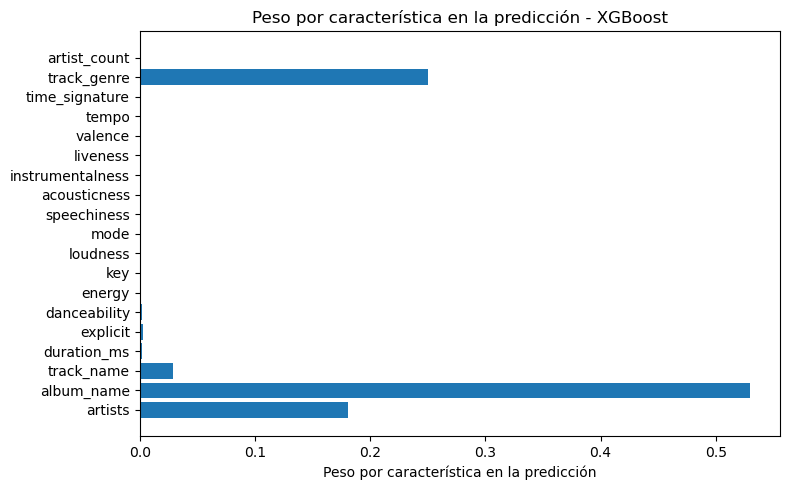

In [71]:
# Visualización básica de la importancia de características
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(X_train.columns, xgb_reg.feature_importances_)
plt.xlabel('Peso por característica en la predicción')
plt.title('Peso por característica en la predicción - XGBoost')
plt.tight_layout()
plt.show()


## **<span style="color:red">hasta aqui hice cambios en XGBoost</span>**


### Punto 6: **Análisis resultados**

Las métricas de rendimiento del modelo XGBoost fueron: <br>
RMSE: $1605.24 <br>
MAE: $1185.23  <br>

Estos resultados presentan uan mejora importante sobre los que se obtuvieron al entrenar el modelo Random Forest con sus parámetrso también por defecto: (RMSE: $1765.41, MAE: $1027.31)

Respecto a la gráfica de "Peso por característica (feature) en la predicción, el mayor peso lo obtuvo el año del automóvil (alrededor del 67%), seguido del modelo Camry XLE (alrededor del 10%) y del millaje (alrededor del 9%).

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [ ]:
# Celda 7
# NOTA: El punto 7 se ha distribuido en varias celdas para facilitar la ejecución y visualización de resultados:

# 1) Importación de la librería GridSearchCV, definión del grid, entrenamiento del modelo y visualización de resultados.
# 2) Análisis resultados XGBoost con calibración de parámetros con el comparativo VS el punto 6
# 3) Análisis del comportamiento de RMSE y MAE para diferentes precios reales VS predichos
# 4) Análisis de la gráfica

# Punto 7 - Calibración de parámetros XGBoost
from sklearn.model_selection import GridSearchCV

# Se define el modelo base
xgb_reg = XGBRegressor(objective='reg:squarederror', random_state=42)

# Se define el grid de parámetros a probar
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'gamma': [0, 0.1, 0.5, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0]
}

# Configuramos la búsqueda con validación cruzada
grid_search = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Se ejecuta la búsqueda de parámetros
grid_search.fit(X_train, y_train)

# Se muestran los mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Se evalua el rendimiento del mejor modelo
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Métricas de rendimiento
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"\nMétricas del modelo XGBoost calibrado:")
print(f"RMSE: ${rmse:.2f}")
print(f"MAE: ${mae:.2f}")

# Comparación con el modelo base
print(f"\nMejora respecto al modelo base:")
print(f"RMSE: ${1605.24 - rmse:.2f} de mejora")
print(f"MAE: ${1185.23 - mae:.2f} de mejora")

# Visualizamos la importancia de características del modelo calibrado
plt.figure(figsize=(7, 4))
plt.barh(X.columns, best_model.feature_importances_)
plt.xlabel('Peso por característica en la predicción')
plt.title('Peso por característica en la predicción - XGBoost calibrado')
plt.tight_layout()
plt.show()

### Punto 7: **Análisis resultados**

Después de calibrar parámetros los resultados fueron:

Fitting 5 folds for each of 48 candidates, totalling 240 fits. Validación cruzada de 5 pliegues, donde las combinaciones de parámetros que se tuvieron en cuenta fueron:  

    'learning_rate': [0.01, 0.05, 0.1, 0.3], (4 opciones)  
    'gamma': [0, 0.1, 0.5, 1.0], (4 opciones)  
    'colsample_bytree': [0.5, 0.7, 1.0], (3 opciones)  
    Total combinaciones: 4 x 4 x 3 = 48 por 5 iteraciones por la validación cruzada.

Mejores parámetros encontrados:
{'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.05}

learning_rate (0.05): Parámetro que controla cuánto contribuye cada árbol al modelo final. El valor óptimo encontrado (0.05) es menor que el valor predeterminado (0.3). Esto indica que un enfoque más conservador funciona mejor para este problema. Un learning_rate más bajo reduce el riesgo de sobreajuste al permitir que el modelo aprenda más gradualmente, a costa de requerir más árboles para alcanzar un rendimiento similar.  

gamma (0): Este parámetro controla la poda mínima requerida para hacer una partición adicional en un nodo de árbol. El valor óptimo de 0 indica que no se necesita una ganancia mínima para crear nuevas divisiones. Nota: se hicieron pruebas con diferentes "escalas" de valores de gamma (por ejemplo, [50, 100, 200 y 500] y luego con [1000, 5000, 10000, 50000]) y no hubo ningún cambio, lo que puede sugerir que para este problema específico, la regularización a través de gamma no es tan crítica como otros parámetros.

colsample_bytree (0.7): Este parámetro determina la fracción de características que se consideran para cada árbol. El valor óptimo de 0.7 significa que cada árbol utiliza aleatoriamente el 70% de las características disponibles. Este valor menor que 1 introduce diversidad entre los árboles, mejorando la generalización del modelo.

Métricas del modelo XGBoost calibrado:<br>
RMSE: $1545.00<br>
MAE: $1133.37<br>

Mejora respecto al modelo base:
RMSE: $60.24 de mejora<br>
MAE: $51.86 de mejora<br>

Respecto a la gráfica de "Peso por característica (feature) en la predicción, hubo un cambio en la distribución de los pesos, respecto al modelo sin  calibración de parámetros. En este caso, el mayor peso lo maantuvo el año del automóvil (bajó del 67% al 65%), seguido ahora del millaje (pasó del 9% al 18%) y luego el modelo Camry XLE (bajó del 10% a alrededor del 6%).

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [ ]:
# Celda 8
# Comparación gráfica de resultados
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

# Predicciones Random Forest Calibrado
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_cal_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valores Reales Precios")
plt.ylabel("Predicciones Precios")
plt.title("Modelo Random Forest Calibrado")

# Predicciones XGBoost Calibrado
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valores Reales Precios")
plt.ylabel("Predicciones Precios")
plt.title("Modelo XGBoost Calibrado")

plt.tight_layout()
plt.show()

In [ ]:
# Valores Residuales
residuals_rf = y_test - y_cal_pred
residuals_xgb = y_test - y_pred
residuals_df = pd.DataFrame({
    'Random Forest': residuals_rf,
    'XGBoost': residuals_xgb
})

# histograms
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plt.hist(residuals_rf, bins=30, alpha=0.7, label='Random Forest')
plt.hist(residuals_xgb, bins=30, alpha=0.7, label='XGBoost')
plt.axvline(0, color='black', linestyle='--')
plt.title('Histograma Residuales')
plt.xlabel('Residuales (Verdaderos - Predichos)')
plt.ylabel('Frecuencia')
plt.legend()

# Plot boxplots
plt.subplot(1, 2, 2)
residuals_df.boxplot()
plt.title('Boxplot Valores Residuales')
plt.ylabel('Residuales (Verdaderos - Predichos)')
plt.axhline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

### Punto 8: **Análisis resultados**

El comportamiento observado en las gráficas anteriores es muy similar. En ambos casos se observa que los modelos tienen mayor dificultad prediciendo valores altos de los precios de los carros. En ambos casos los valores residuales estan centrados alrededor de cero, pero presentan valores atipicos. <br>

Las métricas obtenidas en el conjunto de prueba con los modelos calibrados son las siguientes: <br>

**Modelo Random Forest Calibrado**<br>
RMSE: 1563.10 <br>
MAE : 870.96 <br>

**Modelo XGBoost calibrado:**<br>
RMSE: $1545.00<br>
MAE: $1133.37<br>

Estos resultados hacen dificil sacar las conclusiones dado que por un lado el modelo Random forest tiene un mejor comportamiento en cuanto al MAE 870.93 vs 1133.37, y de otro lado el modelo XGBoost tiene un mejor comportamiento en cuanto al RMSE. Sin embargo la diferencia no es tan significativa. Entonces la elección final del modelo dependería de que nos importa más: 

Si el objetivo es tener predicciones típicamente más precisas, es decir, menor error promedio, el modelo Random Forest es superior, si el objetivo fuera reducir el impacto de errores grandes extremos, XGBoost tendría una ligera ventaja en este aspecto por su mejor manejo de valores anómalos (outliers) ver abajo. sin embargo, dado que el MAE suele ser más intuitivo y facil de explicar porque representa un “error típico” que la mayoría de las predicciones tendrán, creemos que el Random Forest es el mejor modelo en este caso. Adicionamente tiene la ventaja de que es un modelo menos complejo y por tanto más facil de explicar a un público no experto. En tanto que el XGBoost es más dificil de explicar y entender. 

Adicionalmente, es importante mencionar que utilizamos dos tecnicas distintas de calibración, y con la secuencial en el Random Forest pudimos excluir combinaciones de los parámetros a calibrar que dieran aún mejores resultados, pero quisimos explorar la técnica de gridsearch en el punto 7. Finalmente,  en el último renglón incluimos una gráfica que muestra la robustez del modelo XGBoost frente a los valores atípicos. 


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# Usamos los datos de tu taller
# Seleccionamos el año como característica principal para visualización
# X_feature = X_train['Year'].values.reshape(-1, 1)
X_feature = X_train['Mileage'].values.reshape(-1, 1)
y = y_train.values

# Introducir algunos valores extremos para demostrar robustez (opcional)
y_modified = y.copy()
y_modified[np.argmax(X_feature)] = y.max() * 2  # Duplicamos el valor máximo
y_modified[np.argmin(X_feature)] = y.min() * 0.5  # Reducimos el valor mínimo

# Entrenamos modelos XGBoost con diferentes configuraciones
# Modelo con parámetros por defecto
xgb_default = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_default.fit(X_feature, y)

# Modelo con los mejores parámetros encontrados
xgb_optimized = XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.05,
    gamma=0,
    colsample_bytree=0.7,
    random_state=42
)
xgb_optimized.fit(X_feature, y)

# Modelo con datos modificados (para mostrar robustez)
xgb_modified = XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.05,
    gamma=0,
    colsample_bytree=0.7,
    random_state=42
)
xgb_modified.fit(X_feature, y_modified)

# Generar predicciones
X_test = np.linspace(X_feature.min(), X_feature.max(), 500).reshape(-1, 1)
y_pred_default = xgb_default.predict(X_test)
y_pred_optimized = xgb_optimized.predict(X_test)
y_pred_modified = xgb_modified.predict(X_test)

# Configurar el rango del eje Y
y_min = min(y_pred_default.min(), y_pred_optimized.min()) * 0.9
y_max = max(y_pred_default.max(), y_pred_optimized.max()) * 1.1

# Crear gráficos
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# XGBoost por defecto vs optimizado
axs[0].plot(X_test, y_pred_default, color='blue', label="XGBoost (Default)")
axs[0].plot(X_test, y_pred_optimized, color='red', linestyle='dashed', label="XGBoost (Optimized)")
axs[0].set_title("XGBoost: Default vs Optimized Parameters")
axs[0].set_xlabel("Año del vehículo")
axs[0].set_ylabel("Precio predicho ($)")
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

# XGBoost con datos originales vs modificados
axs[1].plot(X_test, y_pred_optimized, color='blue', label="XGBoost (Original Y)")
axs[1].plot(X_test, y_pred_modified, color='red', linestyle='dashed', label="XGBoost (Modified Y)")
axs[1].set_title("XGBoost: Robustez ante valores atípicos")
axs[1].set_xlabel("Año del vehículo")
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()